In [1]:
import catboost
import numpy as np
import pandas as pd

In [2]:
import mlflow

mlflow.set_tracking_uri("sqlite:///mlflow_tracking.db")

mlflow.set_experiment("CatBoost_Baseline")

<Experiment: artifact_location='/home/alxdrzd/alxdrzd/ds-projects/restaurant-visitor-eda/notebooks/mlruns/1', creation_time=1781794553131, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1781794553131, lifecycle_stage='active', name='CatBoost_Baseline', tags={}, trace_location=None, workspace='default'>

In [3]:
from restaurant_visitor_eda.config import PROCESSED_DATA_DIR

df_train = pd.read_csv(PROCESSED_DATA_DIR / "train_features.csv", parse_dates=["visit_date"])
df_test = pd.read_csv(PROCESSED_DATA_DIR / "test_features.csv", parse_dates=["visit_date"])

print(f"Train shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")

2026-06-19 13:41:37.209 | INFO     | restaurant_visitor_eda.config:<module>:11 - PROJ_ROOT path is: /home/alxdrzd/alxdrzd/ds-projects/restaurant-visitor-eda


Train shape: (252108, 28)
Test shape: (32019, 28)


In [4]:
from restaurant_visitor_eda.features import binary_features, categorical_features, numeric_features

features = categorical_features + numeric_features + binary_features

X_full = df_train[features]
y_full = np.log1p(df_train["visitors"].values)

In [5]:
from restaurant_visitor_eda.features import get_custom_cv_splits

cv_splits = get_custom_cv_splits(df_train, n_splits=3, val_days=39)

Fold 1: Train ends 2017-03-14| Val: 2017-03-15 to 2017-04-22
Fold 2: Train ends 2017-02-03| Val: 2017-02-04 to 2017-03-14
Fold 3: Train ends 2016-12-26| Val: 2016-12-27 to 2017-02-03


In [6]:
with mlflow.start_run(run_name="catboost_baseline_cv"):
    mlflow.log_param("iterations", 1500)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("features_count", len(features))
    mlflow.log_param("depth", 8)
    mlflow.log_param("od_wait", 100)
    mlflow.log_param("features", features)

    cv_scores = []
    best_iterations = []

    for fold, (train_idx, val_idx) in enumerate(cv_splits):
        print(f"\n--- Fold {fold + 1} ---")

        X_train, y_train = X_full.iloc[train_idx], y_full[train_idx]
        X_val, y_val = X_full.iloc[val_idx], y_full[val_idx]

        model = catboost.CatBoostRegressor(
            iterations=1500,
            learning_rate=0.05,
            depth=8,
            loss_function="RMSE",
            eval_metric="RMSE",
            cat_features=categorical_features,
            random_seed=42,
            od_type="Iter",
            od_wait=100,
        )

        model.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True, verbose=200)

        best_iter = model.get_best_iteration()
        best_score = model.get_best_score()["validation"]["RMSE"]

        best_iterations.append(best_iter)
        cv_scores.append(best_score)

        mlflow.log_metric(f"rmse_fold_{fold}", best_score)

        print(f"Fold {fold + 1} RMSLE: {best_score:.4f} (Best Iteration: {best_iter})")

    mean_rmsle = np.mean(cv_scores)

    mlflow.log_metric("mean_cv_rmse", mean_rmsle)

    mean_iterations = int(np.mean(best_iterations))

    # optimal_iterations = int(mean_iterations * (len(cv_splits) / (len(cv_splits) - 1)))

    # optimal_iterations = np.max(best_iterations)

    optimal_iterations = mean_iterations

    mlflow.log_param("optimal_iterations", optimal_iterations)

    print(f"\n[Custom Date CV] Mean RMSLE: {mean_rmsle:.4f} ± {np.std(cv_scores):.4f}")

    final_model = catboost.CatBoostRegressor(
        iterations=optimal_iterations,
        learning_rate=0.05,
        depth=8,
        loss_function="RMSE",
        eval_metric="RMSE",
        cat_features=categorical_features,
        random_seed=42,
    )

    final_model.fit(X_full, y_full, verbose=200)
    mlflow.catboost.log_model(final_model, "model")


--- Fold 1 ---
0:	learn: 0.7818547	test: 0.7947523	best: 0.7947523 (0)	total: 136ms	remaining: 3m 23s
200:	learn: 0.5011275	test: 0.5286031	best: 0.5285986 (199)	total: 12.3s	remaining: 1m 19s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.5259050441
bestIteration = 260

Shrink model to first 261 iterations.
Fold 1 RMSLE: 0.5259 (Best Iteration: 260)

--- Fold 2 ---
0:	learn: 0.7838711	test: 0.7870219	best: 0.7870219 (0)	total: 74.9ms	remaining: 1m 52s
200:	learn: 0.5039643	test: 0.4969099	best: 0.4950437 (103)	total: 13.9s	remaining: 1m 29s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.4950436778
bestIteration = 103

Shrink model to first 104 iterations.
Fold 2 RMSLE: 0.4950 (Best Iteration: 103)

--- Fold 3 ---
0:	learn: 0.7839442	test: 0.8102988	best: 0.8102988 (0)	total: 83.8ms	remaining: 2m 5s
200:	learn: 0.5012097	test: 0.4998235	best: 0.4998235 (200)	total: 15.6s	remaining: 1m 40s
Stopped by overfitting detector  (100 iterations wait

2026/06/19 13:43:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


213:	learn: 0.4986456	total: 17.2s	remaining: 0us


2026/06/19 13:43:10 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


In [7]:
X_test = df_test[features]

test_preds_log = final_model.predict(X_test)

test_preds_real = np.expm1(test_preds_log)

test_preds_clipped = np.clip(test_preds_real, 1.0, None)

submission = pd.DataFrame(
    {
        "id": df_test["air_store_id"] + "_" + df_test["visit_date"].dt.strftime("%Y-%m-%d"),
        "visitors": test_preds_clipped,
    }
)

print("Minimal predicted value:", submission["visitors"].min())

submission_path = "submission_catboost_final.csv"
submission.to_csv(submission_path, index=False)

submission.head()

Minimal predicted value: 1.1471242255576066


,id,visitors
0,air_00a91d42b08b08d9_2017-04-23,4.312102
1,air_08cb3c4ee6cd6a22_2017-04-23,13.044449
2,air_f8233ad00755c35c_2017-04-23,4.856823
3,air_234d3dbf7f3d5a50_2017-04-23,7.323838
4,air_a563896da3777078_2017-04-23,27.986661


In [8]:
test_preds_round = np.round(test_preds_clipped)

submission_round = pd.DataFrame(
    {
        "id": df_test["air_store_id"] + "_" + df_test["visit_date"].dt.strftime("%Y-%m-%d"),
        "visitors": test_preds_round,
    }
)

print("Minimal predicted value:", submission_round["visitors"].min())

submission_path = "submission_catboost_final_round.csv"
submission_round.to_csv(submission_path, index=False)

submission_round.head()

Minimal predicted value: 1.0


,id,visitors
0,air_00a91d42b08b08d9_2017-04-23,4.0
1,air_08cb3c4ee6cd6a22_2017-04-23,13.0
2,air_f8233ad00755c35c_2017-04-23,5.0
3,air_234d3dbf7f3d5a50_2017-04-23,7.0
4,air_a563896da3777078_2017-04-23,28.0


/tmp/ipykernel_18503/1554427175.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance[sorted_idx], y=np.array(features)[sorted_idx], palette="viridis")


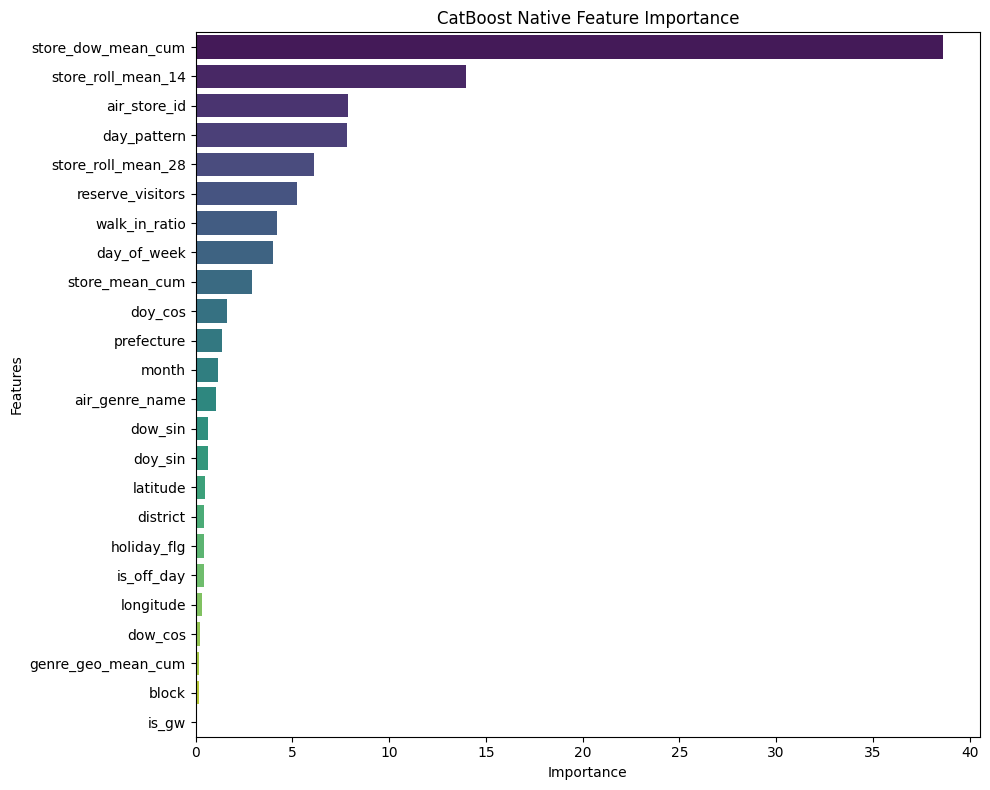

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_importance = final_model.get_feature_importance()
sorted_idx = np.argsort(feature_importance)[::-1]

plt.figure(figsize=(10, 8))
sns.barplot(x=feature_importance[sorted_idx], y=np.array(features)[sorted_idx], palette="viridis")
plt.title("CatBoost Native Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

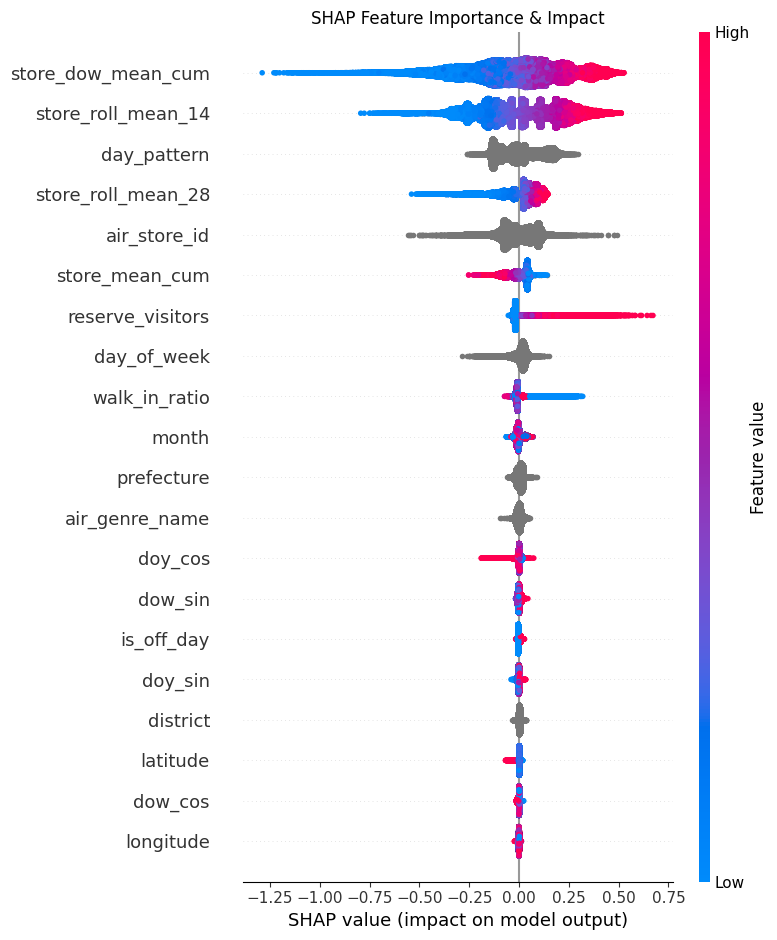

In [10]:
import shap

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_full)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_full, show=False)
plt.title("SHAP Feature Importance & Impact")
plt.tight_layout()
plt.show()